In [1]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


# =====================================================
#  Gaussian Source Utilities
# =====================================================

def gaussian_source(x, y, A, x0, y0, sigma):
    """Single Gaussian source."""
    return A * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))


def multi_gaussian_source(X, Y, params):
    """
    params = [A1, x1, y1, s1, A2, x2, y2, s2, ...]
    """
    n = len(params) // 4
    f = np.zeros_like(X)

    for i in range(n):
        A, x0, y0, s = params[4*i : 4*i + 4]
        f += gaussian_source(X, Y, A, x0, y0, s)

    return f


# =====================================================
#   Helmholtz PDE Solver
#      ∇²u + k²u = f   with u = 0 on ∂Ω
# =====================================================

class HelmholtzSolver:
    """Solve ∇²u + k² u = f on [0,1]² with Dirichlet boundary."""
    
    def __init__(self, n_grid=64, k=np.pi):
        self.n = n_grid
        self.h = 1.0 / (n_grid - 1)
        self.k = k

    def solve(self, source):
        n, h, k = self.n, self.h, self.k
        N = n * n

        # Helmholtz operator L = Δ + k² I
        main = (-4 / h**2 + k**2) * np.ones(N)
        off = (1 / h**2) * np.ones(N - 1)
        off[n - 1::n] = 0  # avoid wrapping
        offy = (1 / h**2) * np.ones(N - n)

        A = diags([main, off, off, offy, offy],
                  [0, 1, -1, n, -n],
                  format="lil")

        b = source.flatten()

        # Dirichlet boundary
        mask = np.zeros((n, n), dtype=bool)
        mask[0, :] = mask[-1, :] = True
        mask[:, 0] = mask[:, -1] = True

        boundary_idx = np.where(mask.flatten())[0]

        for idx in boundary_idx:
            A[idx, :] = 0
            A[idx, idx] = 1
            b[idx] = 0

        u = spsolve(A.tocsr(), b)
        return u.reshape((n, n))


# =====================================================
#   One Helmholtz sample generation
# =====================================================

def generate_helmholtz_sample(n_grid=64, n_sources=2, min_sep=0.25):
    """
    Generates:
        - source field (64×64)
        - solution field (64×64)
        - flattened parameter list
    """
    x = np.linspace(0, 1, n_grid)
    y = np.linspace(0, 1, n_grid)
    X, Y = np.meshgrid(x, y)

    params_raw = []
    centers = []

    for i in range(n_sources):
        while True:
            A = np.random.uniform(2.0, 6.0)
            # A = 2.0 + 4.0 * np.random.beta(2, 2) 
            x0 = np.random.uniform(0.35, 0.65)
            y0 = np.random.uniform(0.35, 0.65)
            # sigma = np.random.uniform(0.05, 0.15)
            sigma = 0.2
            
            ok = True
            for (px, py) in centers:
                if np.sqrt((px - x0)**2 + (py - y0)**2) < min_sep:
                    ok = False
                    break

            if ok:
                centers.append((x0, y0))
                params_raw.append([A, x0, y0, sigma])
                break

    # Sort by x0 to prevent permutation symmetry
    params_raw.sort(key=lambda p: p[1])
    params = [item for p in params_raw for item in p]

    # Source and solution
    source = multi_gaussian_source(X, Y, params)
    solver = HelmholtzSolver(n_grid=n_grid, k=2*np.pi)
    solution = solver.solve(source)

    return source, solution, params


# =====================================================
#   Dataset Generation with Multi-Resolution Sensors
# =====================================================

def generate_helmholtz_dataset(n_samples=500, n_sources=2, n_grid=64,
                               sensors=[16, 32, 48]):
    
    sources = []
    solutions = []
    params_arrays = []

    sensor_vals = {s: [] for s in sensors}
    sensor_x = {}
    sensor_y = {}

    for i in range(n_samples):
        src, sol, par = generate_helmholtz_sample(n_grid, n_sources)

        sources.append(src)
        solutions.append(sol)
        params_arrays.append(par)

        # Sampling solution on coarse grids
        for s in sensors:
            idx = np.linspace(0, n_grid - 1, s).astype(int)
            vals = sol[np.ix_(idx, idx)]
            xs = idx / (n_grid - 1)
            ys = idx / (n_grid - 1)
            Xs, Ys = np.meshgrid(xs, ys)

            sensor_vals[s].append(vals)

            if s not in sensor_x:
                sensor_x[s] = Xs
                sensor_y[s] = Ys

        if (i + 1) % 100 == 0:
            print(f"Generated {i + 1}/{n_samples} samples")

    # Pack dataset
    out = {
        "sources": np.array(sources),
        "solutions": np.array(solutions),
        "params_array": np.array(params_arrays),
    }

    for s in sensors:
        out[f"sensor_{s}x{s}"] = np.array(sensor_vals[s])
        out[f"sensor_{s}x{s}_xcoords"] = sensor_x[s]
        out[f"sensor_{s}x{s}_ycoords"] = sensor_y[s]

    return out


# =====================================================
#            MAIN: Save dataset as NPZ
# =====================================================
if __name__ == "__main__":
    print("Generating Helmholtz dataset...")
    
    data = generate_helmholtz_dataset(
        n_samples=800,
        n_sources=1,
        n_grid=64,
        # sensors=[16, 32, 48]
        sensors=[8, 12, 16, 32]
    )

    np.savez("helmholtz_gaussian_sources_dataset2.npz", **data)

    print("\nSaved: helmholtz_gaussian_sources_dataset2.npz")
    print("Dataset summary:")
    print("sources:", data["sources"].shape)
    print("solutions:", data["solutions"].shape)
    print("params_array:", data["params_array"].shape)
    for s in [8, 12, 16, 32]:
        print(f"sensor_{s}x{s}:", data[f"sensor_{s}x{s}"].shape)


Generating Helmholtz dataset...
Generated 100/800 samples
Generated 200/800 samples
Generated 300/800 samples
Generated 400/800 samples
Generated 500/800 samples
Generated 600/800 samples
Generated 700/800 samples
Generated 800/800 samples

Saved: helmholtz_gaussian_sources_dataset2.npz
Dataset summary:
sources: (800, 64, 64)
solutions: (800, 64, 64)
params_array: (800, 4)
sensor_16x16: (800, 16, 16)
sensor_32x32: (800, 32, 32)


KeyError: 'sensor_48x48'

In [2]:
import numpy as np

data_source = np.load("helmholtz_gaussian_sources_dataset2.npz", allow_pickle=True)

sources = data_source['sources']
solutions = data_source['solutions']
params_array = data_source['params_array']

print("sources: ", sources.shape)
print("solutions: ", solutions.shape)
print("params_array: ", params_array.shape)


sources:  (800, 64, 64)
solutions:  (800, 64, 64)
params_array:  (800, 4)


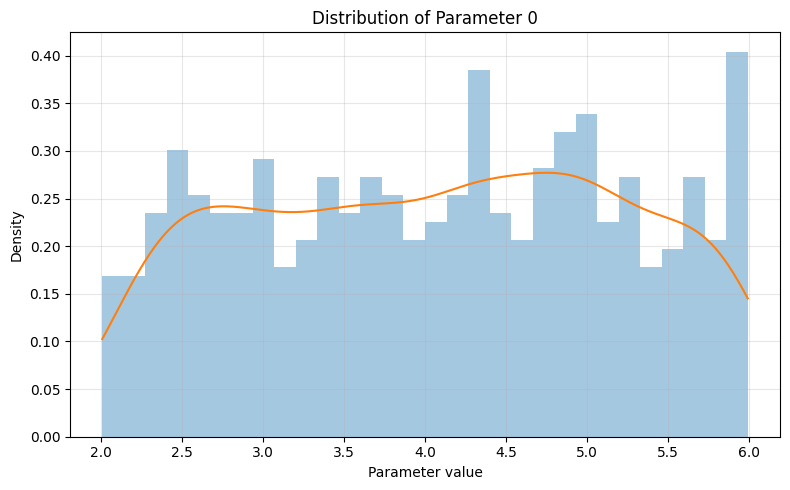

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

data = params_array[:, 0]

# KDE
kde = gaussian_kde(data)
x_vals = np.linspace(data.min(), data.max(), 400)
kde_vals = kde(x_vals)

plt.figure(figsize=(8,5))

# Histogram
plt.hist(data, bins=30, density=True, alpha=0.4)

# KDE curve
plt.plot(x_vals, kde_vals)

plt.title("Distribution of Parameter 0")
plt.xlabel("Parameter value")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


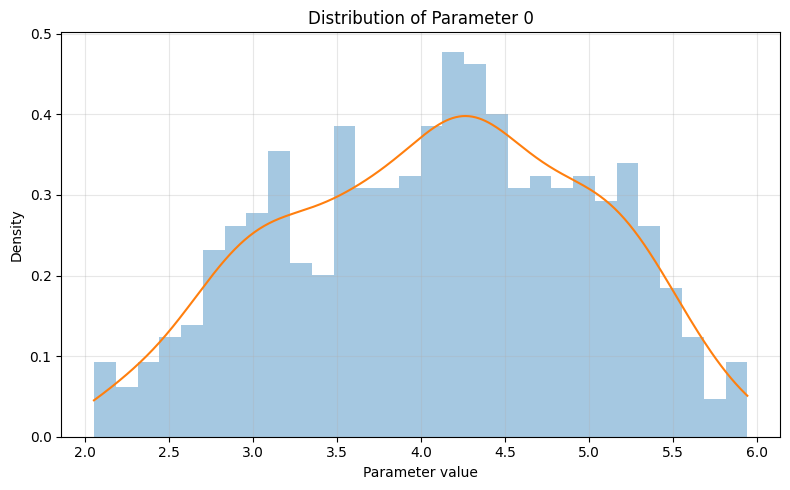

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

data = params_array[:, 0]

# KDE
kde = gaussian_kde(data)
x_vals = np.linspace(data.min(), data.max(), 400)
kde_vals = kde(x_vals)

plt.figure(figsize=(8,5))

# Histogram
plt.hist(data, bins=30, density=True, alpha=0.4)

# KDE curve
plt.plot(x_vals, kde_vals)

plt.title("Distribution of Parameter 0")
plt.xlabel("Parameter value")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



SAMPLE #0 - PARAMETERS

Source 1:
   Amplitude (A1):     5.1914
   Location (x1, y1):  (0.4700, 0.6707)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0006 / 5.1878
   Solution min/max:   -0.1005 / 0.2987



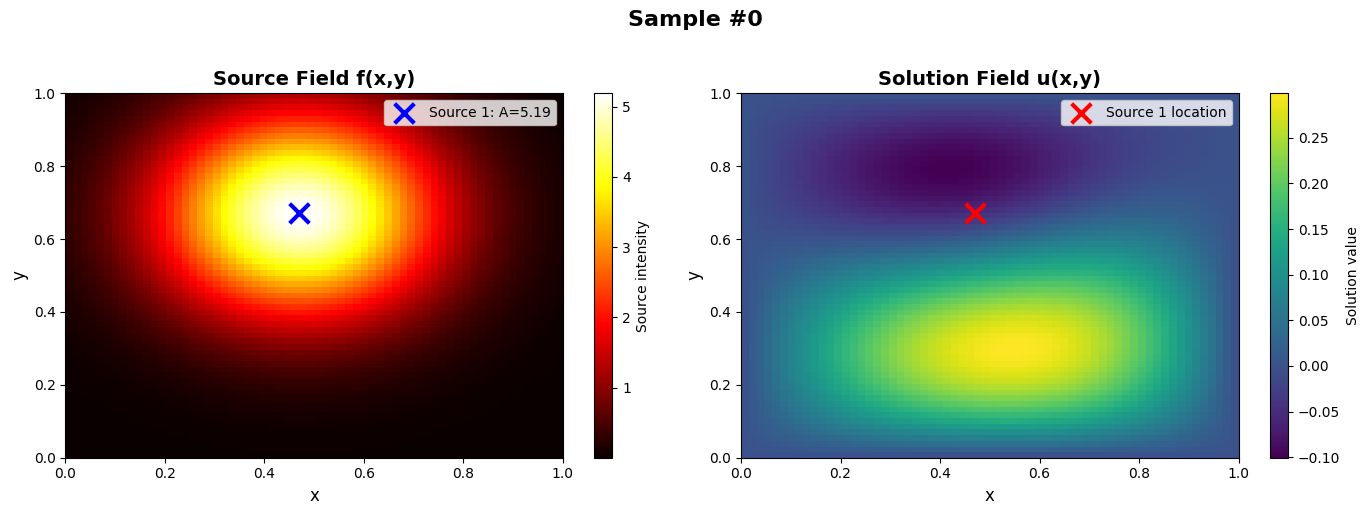


SAMPLE #1 - PARAMETERS

Source 1:
   Amplitude (A1):     5.4604
   Location (x1, y1):  (0.5889, 0.3470)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0003 / 5.4599
   Solution min/max:   -0.1260 / 0.3232



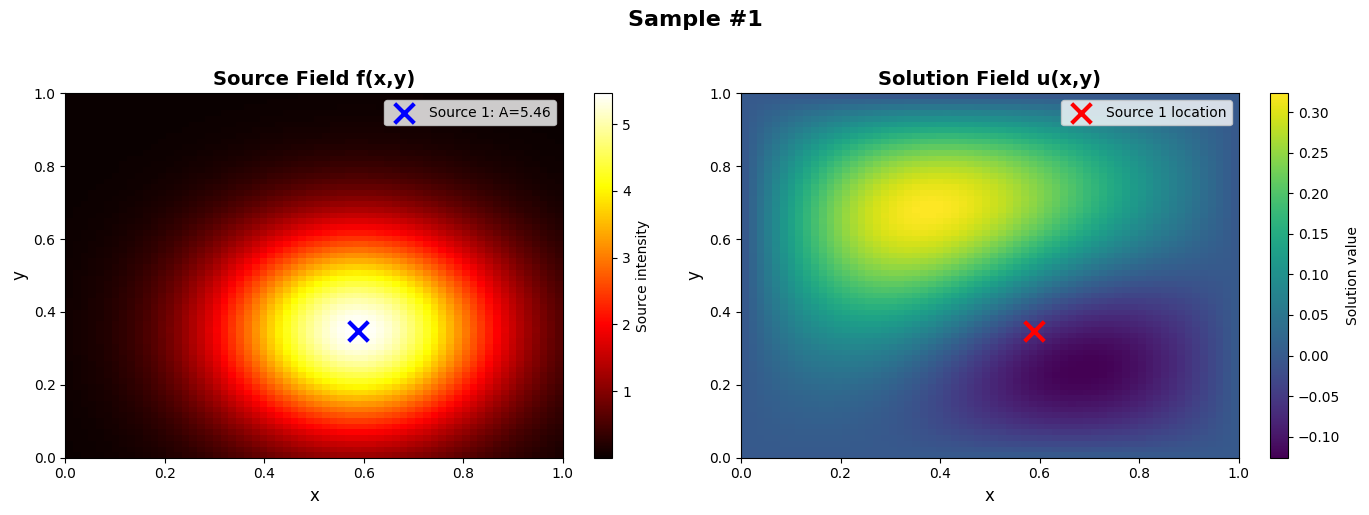


SAMPLE #2 - PARAMETERS

Source 1:
   Amplitude (A1):     2.8061
   Location (x1, y1):  (0.5941, 0.4713)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0010 / 2.8036
   Solution min/max:   -0.0115 / 0.1349



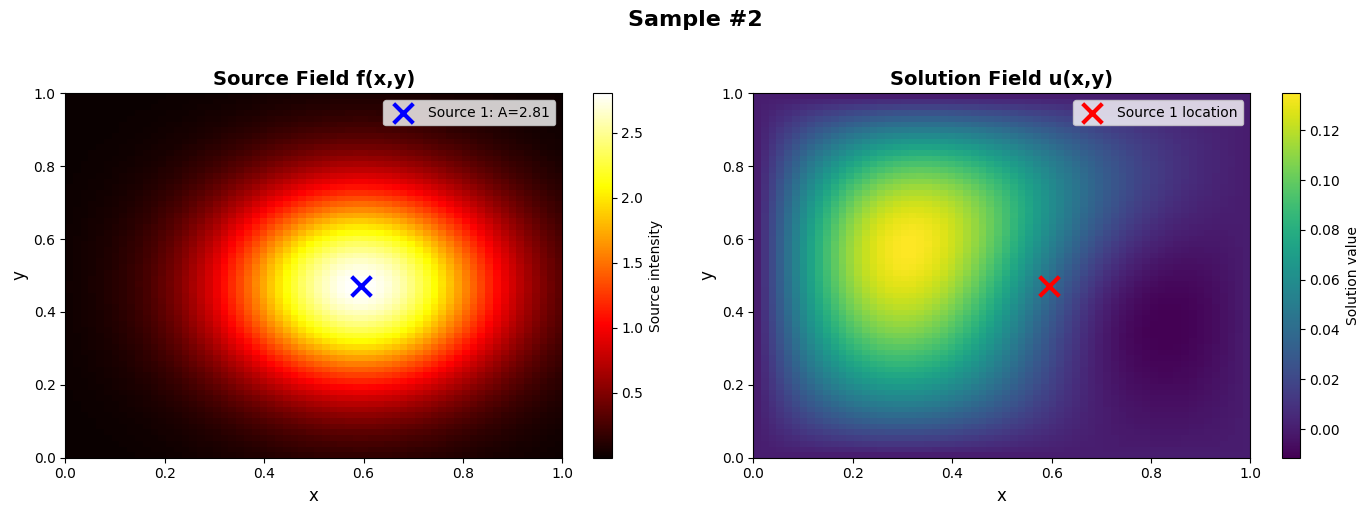


SAMPLE #3 - PARAMETERS

Source 1:
   Amplitude (A1):     4.9916
   Location (x1, y1):  (0.5085, 0.3366)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0008 / 4.9909
   Solution min/max:   -0.0845 / 0.2816



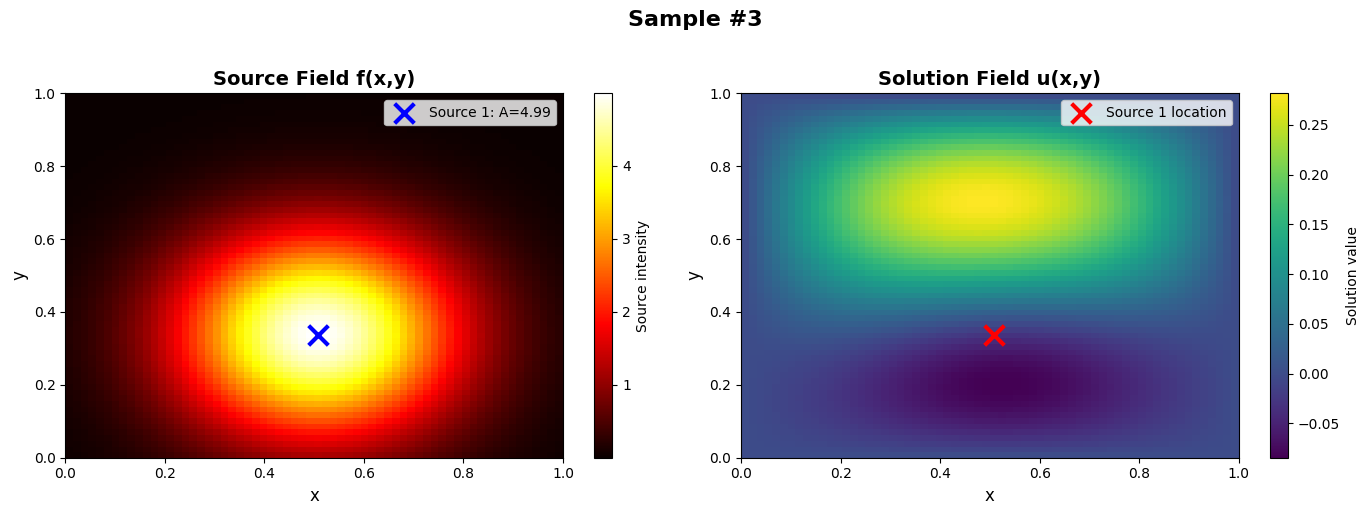


SAMPLE #4 - PARAMETERS

Source 1:
   Amplitude (A1):     4.6765
   Location (x1, y1):  (0.3896, 0.4344)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0008 / 4.6714
   Solution min/max:   -0.0569 / 0.2503



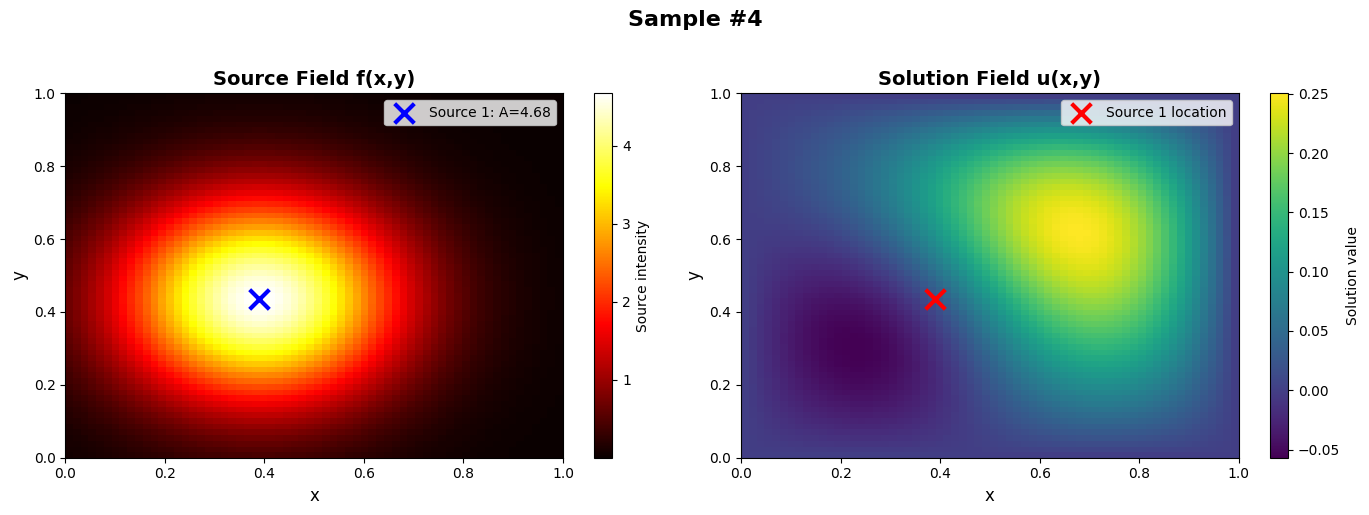

In [6]:
import matplotlib.pyplot as plt

def visualize_sample(idx, sources, solutions, params_array):
    """
    Visualize a single sample with source, solution, and parameters
    
    Parameters for 2 Gaussians:
    [A1, x1, y1, sigma1, A2, x2, y2, sigma2]
    """
    # Extract data
    source = sources[idx]
    solution = solutions[idx]
    params = params_array[idx]
    
    # Parse parameters
    A1, x1, y1, sigma1 = params[0:4]
    # A2, x2, y2, sigma2 = params[4:8]
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Source field f(x,y)
    im1 = axes[0].imshow(source, extent=[0, 1, 0, 1], origin='lower', 
                         cmap='hot', aspect='auto')
    axes[0].scatter([x1], [y1], c='blue', s=200, marker='x', linewidths=3, 
                    label=f'Source 1: A={A1:.2f}')
    # axes[0].scatter([x2], [y2], c='cyan', s=200, marker='x', linewidths=3, 
    #                 label=f'Source 2: A={A2:.2f}')
    axes[0].set_xlabel('x', fontsize=12)
    axes[0].set_ylabel('y', fontsize=12)
    axes[0].set_title(f'Source Field f(x,y)', fontsize=14, fontweight='bold')
    axes[0].legend(loc='upper right', fontsize=10)
    plt.colorbar(im1, ax=axes[0], label='Source intensity')
    
    # Plot 2: Solution field u(x,y)
    im2 = axes[1].imshow(solution, extent=[0, 1, 0, 1], origin='lower', 
                         cmap='viridis', aspect='auto')
    axes[1].scatter([x1], [y1], c='red', s=200, marker='x', linewidths=3, 
                    label='Source 1 location')
    # axes[1].scatter([x2], [y2], c='orange', s=200, marker='x', linewidths=3, 
    #                 label='Source 2 location')
    axes[1].set_xlabel('x', fontsize=12)
    axes[1].set_ylabel('y', fontsize=12)
    axes[1].set_title(f'Solution Field u(x,y)', fontsize=14, fontweight='bold')
    axes[1].legend(loc='upper right', fontsize=10)
    plt.colorbar(im2, ax=axes[1], label='Solution value')
    
    plt.suptitle(f'Sample #{idx}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Print parameters
    print(f"\n{'='*60}")
    print(f"SAMPLE #{idx} - PARAMETERS")
    print(f"{'='*60}")
    print(f"\nSource 1:")
    print(f"   Amplitude (A1):     {A1:.4f}")
    print(f"   Location (x1, y1):  ({x1:.4f}, {y1:.4f})")
    print(f"   Width (σ1):         {sigma1:.4f}")
    
    # print(f"\n Source 2:")
    # print(f"   Amplitude (A2):     {A2:.4f}")
    # print(f"   Location (x2, y2):  ({x2:.4f}, {y2:.4f})")
    # print(f"   Width (σ2):         {sigma2:.4f}")
    
    print(f"\n Statistics:")
    print(f"   Source min/max:     {source.min():.4f} / {source.max():.4f}")
    print(f"   Solution min/max:   {solution.min():.4f} / {solution.max():.4f}")
    # print(f"   Distance between sources: {np.sqrt((x2-x1)**2 + (y2-y1)**2):.4f}")
    print(f"{'='*60}\n")
    
    return fig


# Visualize first 3 samples
for i in range(5):
    fig = visualize_sample(i, sources, solutions, params_array)
    plt.savefig(f'sample_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [5]:
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve


# ---------------------------------------------------
# Gaussian Source
# ---------------------------------------------------
def gaussian_source(X, Y, A, x0, y0, sigma):
    return A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2*sigma**2))


def multi_gaussian(X, Y, params):
    """
    params = [A1, x1, y1, s1,  A2, x2, y2, s2,  ...]
    """
    f = np.zeros_like(X)
    n = len(params) // 4

    for i in range(n):
        A, x0, y0, s = params[4*i : 4*i+4]
        f += gaussian_source(X, Y, A, x0, y0, s)

    return f


# ---------------------------------------------------
# Helmholtz periodic solver
# ∇²u + k² u = f
# ---------------------------------------------------
class HelmholtzPeriodic:
    def __init__(self, n=64, k=2*np.pi):
        self.n = n
        self.h = 1.0 / n
        self.k = k

        # Build matrix once
        self.A = self._build_matrix()

    def _idx(self, i, j):
        n = self.n
        return (i % n) * n + (j % n)

    def _build_matrix(self):
        n, h, k = self.n, self.h, self.k
        N = n*n

        A = lil_matrix((N, N))

        for i in range(n):
            for j in range(n):
                row = self._idx(i, j)

                A[row, self._idx(i+1, j)] = 1/h**2
                A[row, self._idx(i-1, j)] = 1/h**2
                A[row, self._idx(i,   j+1)] = 1/h**2
                A[row, self._idx(i,   j-1)] = 1/h**2

                A[row, row] = -4/h**2 + k**2

        return A.tocsr()

    def solve(self, f):
        u = spsolve(self.A, f.reshape(-1))
        return u.reshape(self.n, self.n)


# ---------------------------------------------------
# Generate ONE sample (source, solution, params)
# ---------------------------------------------------
def generate_sample(n_grid=64, n_gaussians=1, k=2*np.pi):
    x = np.linspace(0, 1, n_grid, endpoint=False)
    y = np.linspace(0, 1, n_grid, endpoint=False)
    X, Y = np.meshgrid(x, y)

    params = []
    cx = []
    cy = []

    # random Gaussian(s)
    for _ in range(n_gaussians):
        A = np.random.uniform(2, 6)
        x0 = np.random.uniform(0.3, 0.7)
        y0 = np.random.uniform(0.3, 0.7)
        s  = 0.20

        params += [A, x0, y0, s]
        cx.append(x0)
        cy.append(y0)

    # generate source
    f = multi_gaussian(X, Y, params)

    # solve Helmholtz
    solver = HelmholtzPeriodic(n=n_grid, k=k)
    u = solver.solve(f)

    return f, u, np.array(params)


# ---------------------------------------------------
# Dataset generator with SENSOR observations
# ---------------------------------------------------
def generate_dataset(n_samples=300,
                     n_grid=64,
                     n_gaussians=1,
                     k=2*np.pi,
                     sensors=[16, 32]):
    """
    Returns dictionary:
        sources          : [N, n, n]
        solutions        : [N, n, n]
        params_array     : [N, 4*n_gaussians]
        sensor_{s}x{s}   : [N, s, s]
        sensor_{s}x{s}_X : (s, s)
        sensor_{s}x{s}_Y : (s, s)
    """
    sources = []
    solutions = []
    params_list = []

    sensor_vals = {s: [] for s in sensors}
    sensor_X = {}
    sensor_Y = {}

    # coarse grids (same for all samples)
    for s in sensors:
        idx = np.linspace(0, n_grid - 1, s).astype(int)
        xs = idx / n_grid
        ys = idx / n_grid
        Xs, Ys = np.meshgrid(xs, ys)
        sensor_X[s] = Xs
        sensor_Y[s] = Ys

    # generate samples
    for i in range(n_samples):
        f, u, params = generate_sample(n_grid=n_grid,
                                       n_gaussians=n_gaussians,
                                       k=k)

        sources.append(f)
        solutions.append(u)
        params_list.append(params)

        # record sensor readings
        for s in sensors:
            idx = np.linspace(0, n_grid - 1, s).astype(int)
            vals = u[np.ix_(idx, idx)]
            sensor_vals[s].append(vals)
            
        if (i + 1) % 2 == 0:
            print(f"Generated {i + 1}/{n_samples} samples")

    # pack output
    out = {
        "sources": np.array(sources),
        "solutions": np.array(solutions),
        "params_array": np.array(params_list),
        "k": k,
        "n_grid": n_grid,
    }

    for s in sensors:
        out[f"sensor_{s}x{s}"] = np.array(sensor_vals[s])
        out[f"sensor_{s}x{s}_xcoords"] = sensor_X[s]
        out[f"sensor_{s}x{s}_ycoords"] = sensor_Y[s]

    return out


# ---------------------------------------------------
# Example
# ---------------------------------------------------
if __name__ == "__main__":
    data = generate_dataset(
        n_samples=20,
        n_grid=64,
        n_gaussians=1,
        k=2*np.pi,
        sensors=[16, 32, 48],
    )

    np.savez("helmholtz_periodic_dataset.npz", **data)

    print("Saved dataset")
    print("sources:", data["sources"].shape)
    print("solutions:", data["solutions"].shape)
    print("params:", data["params_array"].shape)


Generated 2/20 samples
Generated 4/20 samples
Generated 6/20 samples
Generated 8/20 samples
Generated 10/20 samples
Generated 12/20 samples
Generated 14/20 samples
Generated 16/20 samples
Generated 18/20 samples
Generated 20/20 samples
Saved dataset
sources: (20, 64, 64)
solutions: (20, 64, 64)
params: (20, 4)


In [6]:
import numpy as np

data_source = np.load("helmholtz_periodic_dataset.npz", allow_pickle=True)

sources = data_source['sources']
solutions = data_source['solutions']
params_array = data_source['params_array']

print("sources: ", sources.shape)
print("solutions: ", solutions.shape)
print("params_array: ", params_array.shape)


sources:  (20, 64, 64)
solutions:  (20, 64, 64)
params_array:  (20, 4)



SAMPLE #0 - PARAMETERS

Source 1:
   Amplitude (A1):     5.5154
   Location (x1, y1):  (0.5188, 0.5471)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0045 / 5.5147
   Solution min/max:   -80.4552 / 80.4589



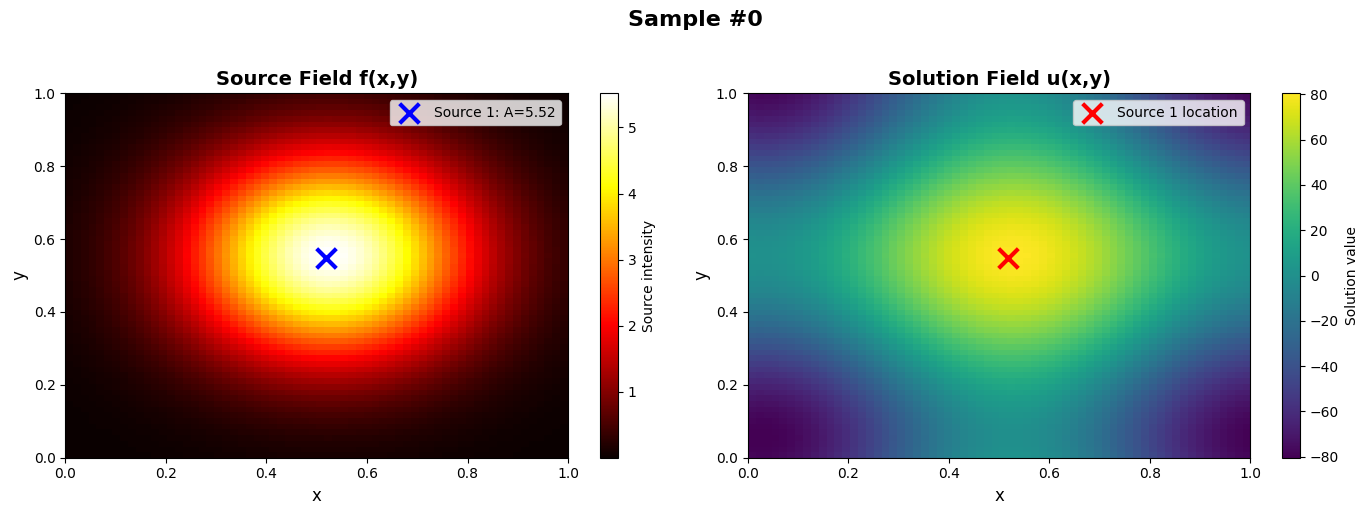


SAMPLE #1 - PARAMETERS

Source 1:
   Amplitude (A1):     5.6055
   Location (x1, y1):  (0.4833, 0.4506)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0069 / 5.6050
   Solution min/max:   -81.6792 / 81.6832



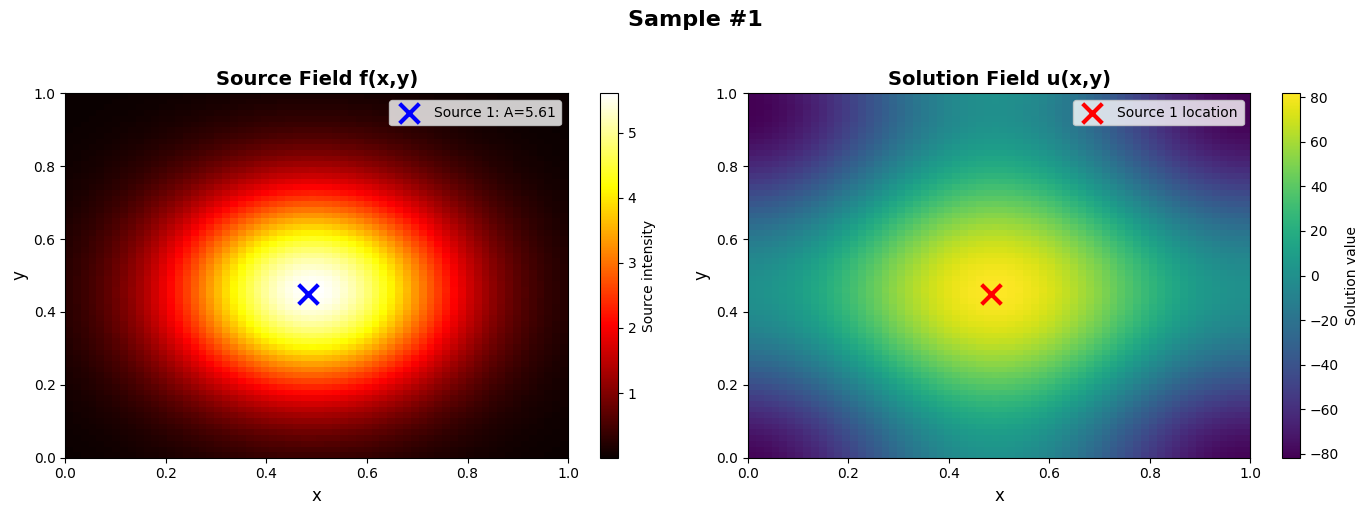


SAMPLE #2 - PARAMETERS

Source 1:
   Amplitude (A1):     2.4388
   Location (x1, y1):  (0.6115, 0.5715)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0004 / 2.4373
   Solution min/max:   -35.8575 / 35.8578



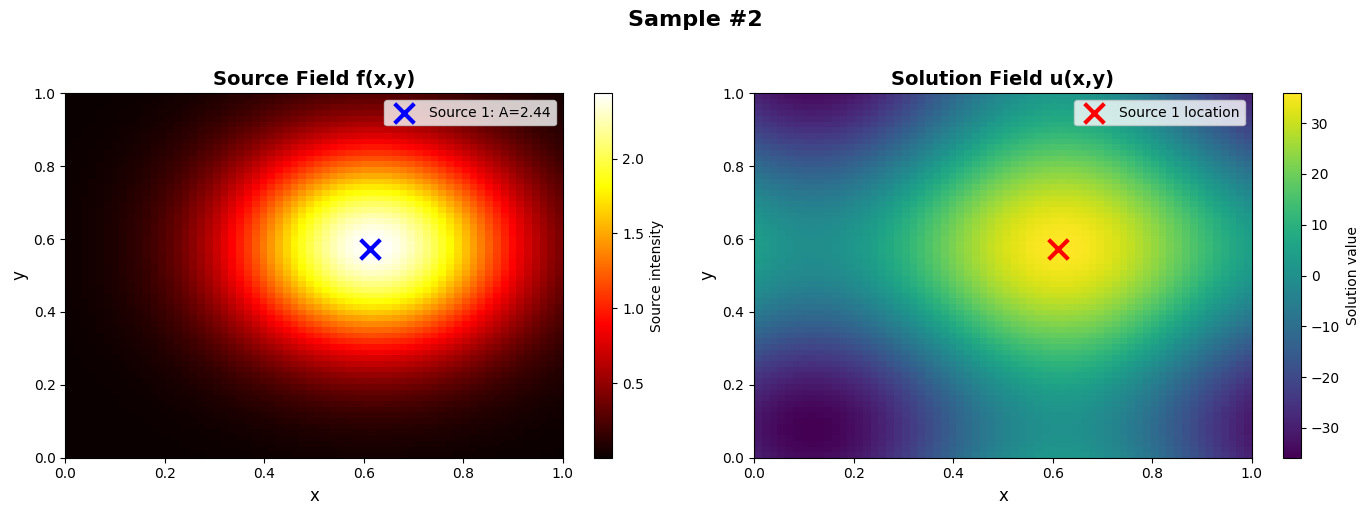


SAMPLE #3 - PARAMETERS

Source 1:
   Amplitude (A1):     5.3026
   Location (x1, y1):  (0.4022, 0.6021)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0008 / 5.2979
   Solution min/max:   -77.9719 / 77.9725



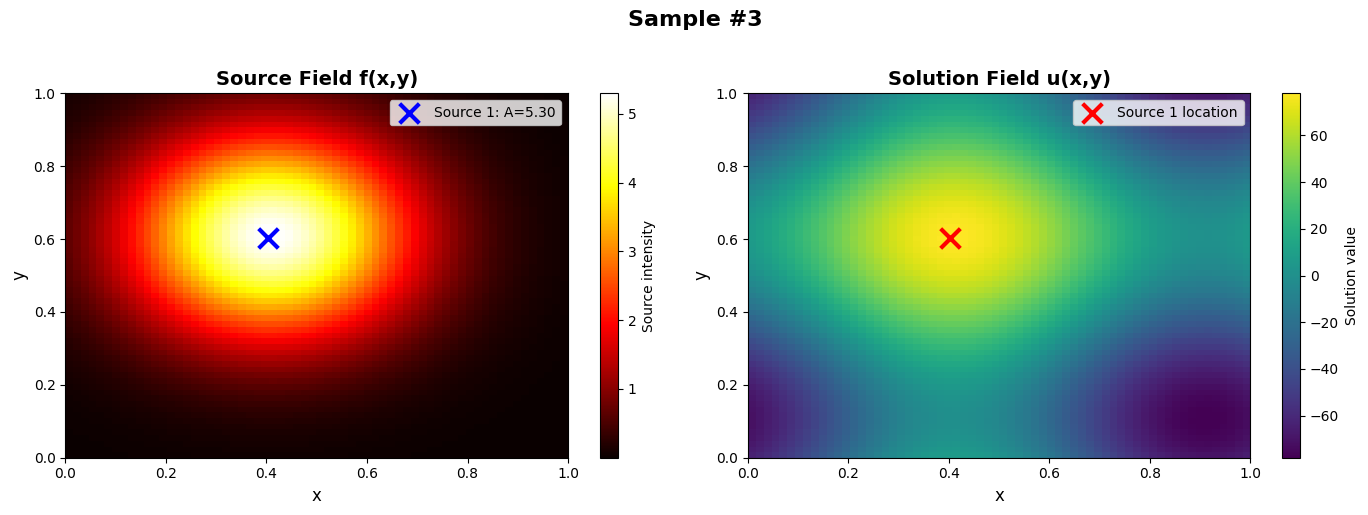


SAMPLE #4 - PARAMETERS

Source 1:
   Amplitude (A1):     3.4613
   Location (x1, y1):  (0.3057, 0.5945)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0001 / 3.4592
   Solution min/max:   -51.1622 / 51.1591



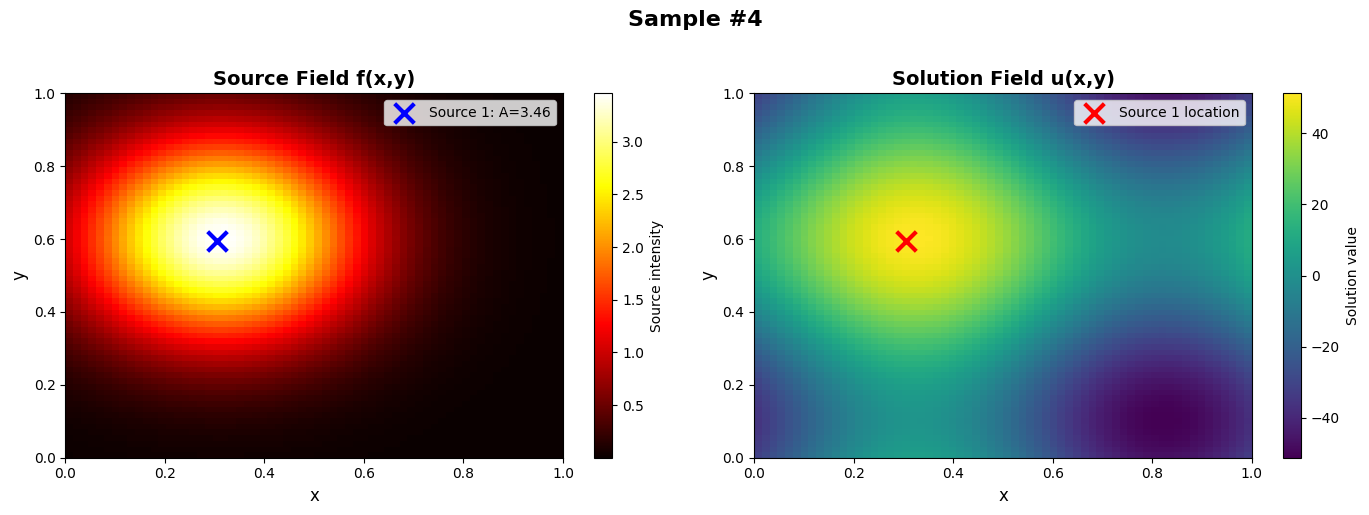

In [7]:
import matplotlib.pyplot as plt

def visualize_sample(idx, sources, solutions, params_array):
    """
    Visualize a single sample with source, solution, and parameters
    
    Parameters for 2 Gaussians:
    [A1, x1, y1, sigma1, A2, x2, y2, sigma2]
    """
    # Extract data
    source = sources[idx]
    solution = solutions[idx]
    params = params_array[idx]
    
    # Parse parameters
    A1, x1, y1, sigma1 = params[0:4]
    # A2, x2, y2, sigma2 = params[4:8]
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Source field f(x,y)
    im1 = axes[0].imshow(source, extent=[0, 1, 0, 1], origin='lower', 
                         cmap='hot', aspect='auto')
    axes[0].scatter([x1], [y1], c='blue', s=200, marker='x', linewidths=3, 
                    label=f'Source 1: A={A1:.2f}')
    # axes[0].scatter([x2], [y2], c='cyan', s=200, marker='x', linewidths=3, 
    #                 label=f'Source 2: A={A2:.2f}')
    axes[0].set_xlabel('x', fontsize=12)
    axes[0].set_ylabel('y', fontsize=12)
    axes[0].set_title(f'Source Field f(x,y)', fontsize=14, fontweight='bold')
    axes[0].legend(loc='upper right', fontsize=10)
    plt.colorbar(im1, ax=axes[0], label='Source intensity')
    
    # Plot 2: Solution field u(x,y)
    im2 = axes[1].imshow(solution, extent=[0, 1, 0, 1], origin='lower', 
                         cmap='viridis', aspect='auto')
    axes[1].scatter([x1], [y1], c='red', s=200, marker='x', linewidths=3, 
                    label='Source 1 location')
    # axes[1].scatter([x2], [y2], c='orange', s=200, marker='x', linewidths=3, 
    #                 label='Source 2 location')
    axes[1].set_xlabel('x', fontsize=12)
    axes[1].set_ylabel('y', fontsize=12)
    axes[1].set_title(f'Solution Field u(x,y)', fontsize=14, fontweight='bold')
    axes[1].legend(loc='upper right', fontsize=10)
    plt.colorbar(im2, ax=axes[1], label='Solution value')
    
    plt.suptitle(f'Sample #{idx}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Print parameters
    print(f"\n{'='*60}")
    print(f"SAMPLE #{idx} - PARAMETERS")
    print(f"{'='*60}")
    print(f"\nSource 1:")
    print(f"   Amplitude (A1):     {A1:.4f}")
    print(f"   Location (x1, y1):  ({x1:.4f}, {y1:.4f})")
    print(f"   Width (σ1):         {sigma1:.4f}")
    
    # print(f"\n Source 2:")
    # print(f"   Amplitude (A2):     {A2:.4f}")
    # print(f"   Location (x2, y2):  ({x2:.4f}, {y2:.4f})")
    # print(f"   Width (σ2):         {sigma2:.4f}")
    
    print(f"\n Statistics:")
    print(f"   Source min/max:     {source.min():.4f} / {source.max():.4f}")
    print(f"   Solution min/max:   {solution.min():.4f} / {solution.max():.4f}")
    # print(f"   Distance between sources: {np.sqrt((x2-x1)**2 + (y2-y1)**2):.4f}")
    print(f"{'='*60}\n")
    
    return fig


# Visualize first 3 samples
for i in range(5):
    fig = visualize_sample(i, sources, solutions, params_array)
    plt.savefig(f'sample_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [4]:
import numpy as np
from scipy.sparse import diags, lil_matrix
from scipy.sparse.linalg import spsolve


# =====================================================
#  Gaussian Source Utilities
# =====================================================

def gaussian_source(x, y, A, x0, y0, sigma):
    """Single Gaussian source."""
    return A * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))


def multi_gaussian_source(X, Y, params):
    """
    params = [A1, x1, y1, s1, A2, x2, y2, s2, ...]
    """
    n = len(params) // 4
    f = np.zeros_like(X)

    for i in range(n):
        A, x0, y0, s = params[4*i : 4*i + 4]
        f += gaussian_source(X, Y, A, x0, y0, s)

    return f


# =====================================================
#   Helmholtz Solver with PERIODIC BC
#      ∇²u + k²u = f   with periodic boundaries
# =====================================================

class HelmholtzPeriodicSolver:
    """
    Solve ∇²u + k²u = f on [0,1]² with periodic BC:
    - u(0,y) = u(1,y)
    - u(x,0) = u(x,1)
    """
    
    def __init__(self, n_grid=64, k=np.pi):
        self.n = n_grid
        self.h = 1.0 / n_grid  # Note: for periodic, h = L/n (not n-1)
        self.k = k

    def solve(self, source):
        n, h, k = self.n, self.h, self.k
        N = n * n

        # Build periodic Laplacian matrix
        A = lil_matrix((N, N))
        b = source.flatten()

        # Helper function to convert 2D indices to 1D
        def idx(i, j):
            # Periodic wraparound
            i = i % n
            j = j % n
            return i * n + j

        # Build the system with periodic stencil
        for i in range(n):
            for j in range(n):
                row = idx(i, j)
                
                # 5-point stencil with periodic wraparound
                # u[i,j] is connected to: u[i±1,j] and u[i,j±1]
                # with wraparound at boundaries
                
                A[row, idx(i+1, j)] = 1 / h**2  # up (wraps at top)
                A[row, idx(i-1, j)] = 1 / h**2  # down (wraps at bottom)
                A[row, idx(i, j+1)] = 1 / h**2  # right (wraps at right edge)
                A[row, idx(i, j-1)] = 1 / h**2  # left (wraps at left edge)
                A[row, row] = -4 / h**2 + k**2  # center

        # Convert to CSR format for efficient solving
        A_csr = A.tocsr()
        
        # For k=0 (Poisson), check compatibility condition
        if abs(k) < 1e-10:
            source_integral = np.sum(source) * h**2
            if abs(source_integral) > 1e-8:
                print(f"Warning: Source integral = {source_integral:.6f} (should be ~0 for Poisson)")
                # Adjust source to satisfy compatibility
                source_adj = source - np.mean(source)
                b = source_adj.flatten()
        
        # Solve the system
        u = spsolve(A_csr, b)
        
        return u.reshape((n, n))


# =====================================================
#   Poisson Solver with Periodic BC (for comparison)
# =====================================================

class PoissonPeriodicSolver:
    """
    Solve ∇²u = f with periodic BC.
    Note: Source must satisfy ∫∫ f dx dy = 0 (compatibility condition)
    Solution is unique up to a constant - we fix by setting mean(u) = 0
    """
    
    def __init__(self, n_grid=64):
        self.n = n_grid
        self.h = 1.0 / n_grid

    def solve(self, source):
        n, h = self.n, self.h
        N = n * n

        # Ensure compatibility: subtract mean from source
        source_centered = source - np.mean(source)
        
        # Build periodic Laplacian
        A = lil_matrix((N, N))
        b = source_centered.flatten()

        def idx(i, j):
            i = i % n
            j = j % n
            return i * n + j

        for i in range(n):
            for j in range(n):
                row = idx(i, j)
                
                A[row, idx(i+1, j)] = 1 / h**2
                A[row, idx(i-1, j)] = 1 / h**2
                A[row, idx(i, j+1)] = 1 / h**2
                A[row, idx(i, j-1)] = 1 / h**2
                A[row, row] = -4 / h**2

        # Fix constant: set u at one point to zero (remove null space)
        # This makes the solution unique
        A[0, :] = 0
        A[0, 0] = 1
        b[0] = 0
        
        A_csr = A.tocsr()
        u = spsolve(A_csr, b)
        
        return u.reshape((n, n))


# =====================================================
#   Sample generation with periodic BC
# =====================================================

def generate_helmholtz_sample(n_grid=64, n_sources=1, min_sep=0.25, 
                              solver_type='helmholtz_periodic', k=2*np.pi):
    """
    Generates:
        - source field (64×64)
        - solution field (64×64) with periodic BC
        - flattened parameter list
    
    solver_type:
        'helmholtz_periodic': Helmholtz with periodic BC (RECOMMENDED)
        'poisson_periodic': Poisson with periodic BC
    """
    x = np.linspace(0, 1, n_grid, endpoint=False)  # Note: endpoint=False for periodic
    y = np.linspace(0, 1, n_grid, endpoint=False)
    X, Y = np.meshgrid(x, y)

    params_raw = []
    centers = []

    for i in range(n_sources):
        while True:
            A = np.random.uniform(0.1, 1.0)
            x0 = np.random.uniform(0.3, 0.7)
            y0 = np.random.uniform(0.3, 0.7)
            sigma = 0.2
            
            ok = True
            for (px, py) in centers:
                if np.sqrt((px - x0)**2 + (py - y0)**2) < min_sep:
                    ok = False
                    break

            if ok:
                centers.append((x0, y0))
                params_raw.append([A, x0, y0, sigma])
                break

    # Sort by x0 to prevent permutation symmetry
    params_raw.sort(key=lambda p: p[1])
    params = [item for p in params_raw for item in p]

    # Generate source
    source = multi_gaussian_source(X, Y, params)
    
    # Solve with chosen method
    if solver_type == 'helmholtz_periodic':
        solver = HelmholtzPeriodicSolver(n_grid=n_grid, k=k)
    elif solver_type == 'poisson_periodic':
        solver = PoissonPeriodicSolver(n_grid=n_grid)
    else:
        raise ValueError(f"Unknown solver_type: {solver_type}")
    
    solution = solver.solve(source)

    return source, solution, params


# =====================================================
#   Dataset Generation
# =====================================================

def generate_helmholtz_dataset(n_samples=500, n_sources=1, n_grid=64,
                               sensors=[16, 32, 48], 
                               solver_type='helmholtz_periodic',
                               k=2*np.pi):
    
    sources = []
    solutions = []
    params_arrays = []

    sensor_vals = {s: [] for s in sensors}
    sensor_x = {}
    sensor_y = {}

    for i in range(n_samples):
        src, sol, par = generate_helmholtz_sample(
            n_grid, n_sources, solver_type=solver_type, k=k
        )

        sources.append(src)
        solutions.append(sol)
        params_arrays.append(par)

        # Sampling solution on coarse grids
        for s in sensors:
            idx = np.linspace(0, n_grid - 1, s).astype(int)
            vals = sol[np.ix_(idx, idx)]
            xs = idx / n_grid  # Note: divide by n_grid (not n_grid-1)
            ys = idx / n_grid
            Xs, Ys = np.meshgrid(xs, ys)

            sensor_vals[s].append(vals)

            if s not in sensor_x:
                sensor_x[s] = Xs
                sensor_y[s] = Ys

        if (i + 1) % 100 == 0:
            print(f"Generated {i + 1}/{n_samples} samples")

    # Pack dataset
    out = {
        "sources": np.array(sources),
        "solutions": np.array(solutions),
        "params_array": np.array(params_arrays),
        "solver_type": solver_type,
        "k": k,
    }

    for s in sensors:
        out[f"sensor_{s}x{s}"] = np.array(sensor_vals[s])
        out[f"sensor_{s}x{s}_xcoords"] = sensor_x[s]
        out[f"sensor_{s}x{s}_ycoords"] = sensor_y[s]

    return out


# =====================================================
#            MAIN: Generate and Compare
# =====================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Generating Helmholtz dataset with PERIODIC BC")
    print("=" * 60)
    
    # Test different k values with periodic BC
    # k_values = [np.pi, 2*np.pi, 3*np.pi]
    k_values = [2*np.pi]
    
    
    for k in k_values:
        print(f"\n=== k = {k/np.pi:.1f}π ===")
        
        data = generate_helmholtz_dataset(
            n_samples=500,
            n_sources=1,
            n_grid=64,
            sensors=[16, 32, 48],
            solver_type='helmholtz_periodic',
            k=k
        )

        filename = f"helmholtz_periodic_k{k/np.pi:.1f}pi.npz"
        np.savez(filename, **data)

        print(f"Saved: {filename}")
        print("  sources:", data["sources"].shape)
        print("  solutions:", data["solutions"].shape)
        print("  params_array:", data["params_array"].shape)
    
#     # Visualization: Compare periodic vs Dirichlet
#     import matplotlib.pyplot as plt
    
#     print("\n" + "=" * 60)
#     print("Creating comparison: Periodic vs Dirichlet BC")
#     print("=" * 60)
    
#     np.random.seed(42)
#     n_grid = 64
#     x = np.linspace(0, 1, n_grid, endpoint=False)
#     y = np.linspace(0, 1, n_grid, endpoint=False)
#     X, Y = np.meshgrid(x, y)
    
#     # Same source for comparison
#     A, x0, y0, sigma = 4.0, 0.5, 0.5, 0.2
#     source = gaussian_source(X, Y, A, x0, y0, sigma)
    
#     fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
#     # Plot source
#     im0 = axes[0, 0].imshow(source, extent=[0,1,0,1], origin='lower', cmap='hot')
#     axes[0, 0].set_title(f'Source\n(A={A:.1f}, center=({x0},{y0}))')
#     axes[0, 0].set_xlabel('x')
#     axes[0, 0].set_ylabel('y')
#     plt.colorbar(im0, ax=axes[0, 0])
    
#     # Solve with different BC
#     from scipy.sparse import diags
    
#     # 1. Periodic BC
#     solver_periodic = HelmholtzPeriodicSolver(n_grid=n_grid, k=2*np.pi)
#     sol_periodic = solver_periodic.solve(source)
    
#     im1 = axes[0, 1].imshow(sol_periodic, extent=[0,1,0,1], origin='lower', cmap='viridis')
#     axes[0, 1].set_title(f'Periodic BC\nRange: [{sol_periodic.min():.3f}, {sol_periodic.max():.3f}]')
#     plt.colorbar(im1, ax=axes[0, 1])
    
#     # 2. Dirichlet BC (from original code)
#     from scipy.sparse.linalg import spsolve
    
#     n, h, k = n_grid, 1.0/(n_grid-1), 2*np.pi
#     N = n * n
#     main = (-4 / h**2 + k**2) * np.ones(N)
#     off = (1 / h**2) * np.ones(N - 1)
#     off[n - 1::n] = 0
#     offy = (1 / h**2) * np.ones(N - n)
    
#     A_dir = diags([main, off, off, offy, offy], [0, 1, -1, n, -n], format="lil")
#     b_dir = source.flatten()
    
#     # Dirichlet BC
#     mask = np.zeros((n, n), dtype=bool)
#     mask[0, :] = mask[-1, :] = True
#     mask[:, 0] = mask[:, -1] = True
#     boundary_idx = np.where(mask.flatten())[0]
    
#     for idx in boundary_idx:
#         A_dir[idx, :] = 0
#         A_dir[idx, idx] = 1
#         b_dir[idx] = 0
    
#     sol_dirichlet = spsolve(A_dir.tocsr(), b_dir).reshape((n, n))
    
#     im2 = axes[0, 2].imshow(sol_dirichlet, extent=[0,1,0,1], origin='lower', cmap='viridis')
#     axes[0, 2].set_title(f'Dirichlet BC (u=0)\nRange: [{sol_dirichlet.min():.3f}, {sol_dirichlet.max():.3f}]')
#     plt.colorbar(im2, ax=axes[0, 2])
    
#     # Bottom row: Cross-sections
#     mid = n_grid // 2
    
#     # Horizontal cross-section
#     axes[1, 0].plot(x, source[mid, :], 'r-', linewidth=2, label='Source')
#     axes[1, 0].set_title('Horizontal Cross-section (y=0.5)')
#     axes[1, 0].set_xlabel('x')
#     axes[1, 0].legend()
#     axes[1, 0].grid(True, alpha=0.3)
    
#     axes[1, 1].plot(x, sol_periodic[mid, :], 'b-', linewidth=2, label='Periodic')
#     axes[1, 1].set_title('Solution Cross-section (Periodic)')
#     axes[1, 1].set_xlabel('x')
#     axes[1, 1].set_ylabel('u')
#     axes[1, 1].legend()
#     axes[1, 1].grid(True, alpha=0.3)
#     axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Boundary')
#     axes[1, 1].axvline(x=1, color='gray', linestyle='--', alpha=0.5)
    
#     x_dir = np.linspace(0, 1, n_grid)
#     axes[1, 2].plot(x_dir, sol_dirichlet[mid, :], 'g-', linewidth=2, label='Dirichlet')
#     axes[1, 2].set_title('Solution Cross-section (Dirichlet)')
#     axes[1, 2].set_xlabel('x')
#     axes[1, 2].legend()
#     axes[1, 2].grid(True, alpha=0.3)
#     axes[1, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='u=0')
#     axes[1, 2].axvline(x=1, color='red', linestyle='--', alpha=0.5)
    
#     plt.tight_layout()
#     plt.savefig('periodic_vs_dirichlet.png', dpi=150)
#     print("\nComparison saved: periodic_vs_dirichlet.png")
    
#     # Statistics
#     print("\n=== Solution Statistics ===")
#     print(f"Periodic BC:")
#     print(f"  Min: {sol_periodic.min():.4f}")
#     print(f"  Max: {sol_periodic.max():.4f}")
#     print(f"  Range: {sol_periodic.max() - sol_periodic.min():.4f}")
#     print(f"  Mean: {sol_periodic.mean():.4f}")
#     print(f"  Std: {sol_periodic.std():.4f}")
    
#     print(f"\nDirichlet BC:")
#     print(f"  Min: {sol_dirichlet.min():.4f}")
#     print(f"  Max: {sol_dirichlet.max():.4f}")
#     print(f"  Range: {sol_dirichlet.max() - sol_dirichlet.min():.4f}")
#     print(f"  Mean: {sol_dirichlet.mean():.4f}")
#     print(f"  Std: {sol_dirichlet.std():.4f}")
    
#     print(f"\nAmplitude preservation:")
#     print(f"  Source max: {source.max():.4f}")
#     print(f"  Periodic solution range: {sol_periodic.max() - sol_periodic.min():.4f}")
#     print(f"  Dirichlet solution range: {sol_dirichlet.max() - sol_dirichlet.min():.4f}")
#     print(f"  Periodic preserves {100*(sol_periodic.max()-sol_periodic.min())/(sol_dirichlet.max()-sol_dirichlet.min()):.1f}% more amplitude")


Generating Helmholtz dataset with PERIODIC BC

=== k = 2.0π ===
Generated 100/500 samples
Generated 200/500 samples
Generated 300/500 samples
Generated 400/500 samples
Generated 500/500 samples
Saved: helmholtz_periodic_k2.0pi.npz
  sources: (500, 64, 64)
  solutions: (500, 64, 64)
  params_array: (500, 4)


In [5]:
import numpy as np

data_source = np.load("helmholtz_periodic_k2.0pi.npz", allow_pickle=True)
# scr4_sgoswam4/Dibakar/INV_DON/helmholtz_source_ID/helmholtz_periodic_k2.0pi.npz
sources = data_source['sources']
solutions = data_source['solutions']
params_array = data_source['params_array']

print("sources: ", sources.shape)
print("solutions: ", solutions.shape)
print("params_array: ", params_array.shape)


sources:  (500, 64, 64)
solutions:  (500, 64, 64)
params_array:  (500, 4)



SAMPLE #0 - PARAMETERS

Source 1:
   Amplitude (A1):     0.6469
   Location (x1, y1):  (0.3681, 0.5012)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0002 / 0.6465
   Solution min/max:   -9.4878 / 9.4879



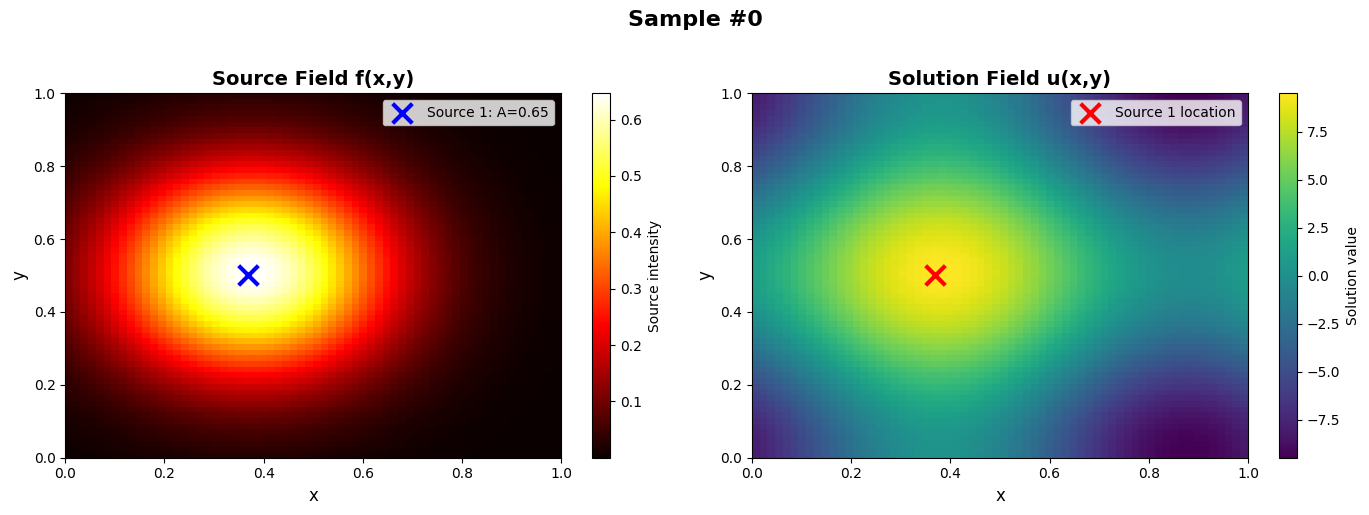


SAMPLE #1 - PARAMETERS

Source 1:
   Amplitude (A1):     0.8413
   Location (x1, y1):  (0.3166, 0.4666)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0001 / 0.8411
   Solution min/max:   -12.3820 / 12.3817



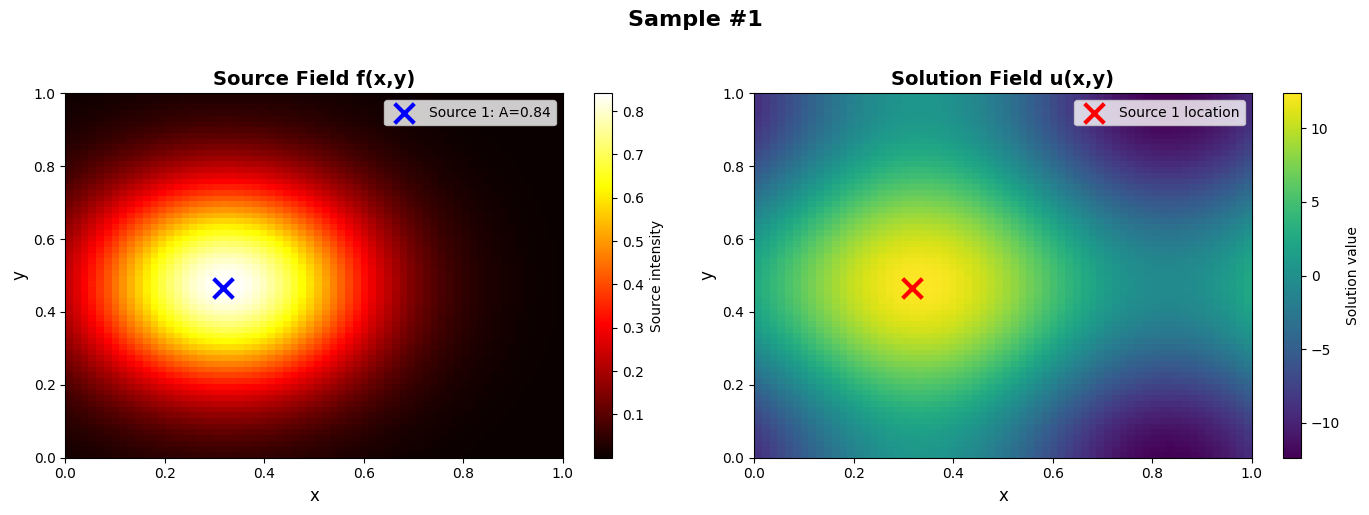


SAMPLE #2 - PARAMETERS

Source 1:
   Amplitude (A1):     0.6447
   Location (x1, y1):  (0.4439, 0.5483)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0004 / 0.6443
   Solution min/max:   -9.4108 / 9.4112



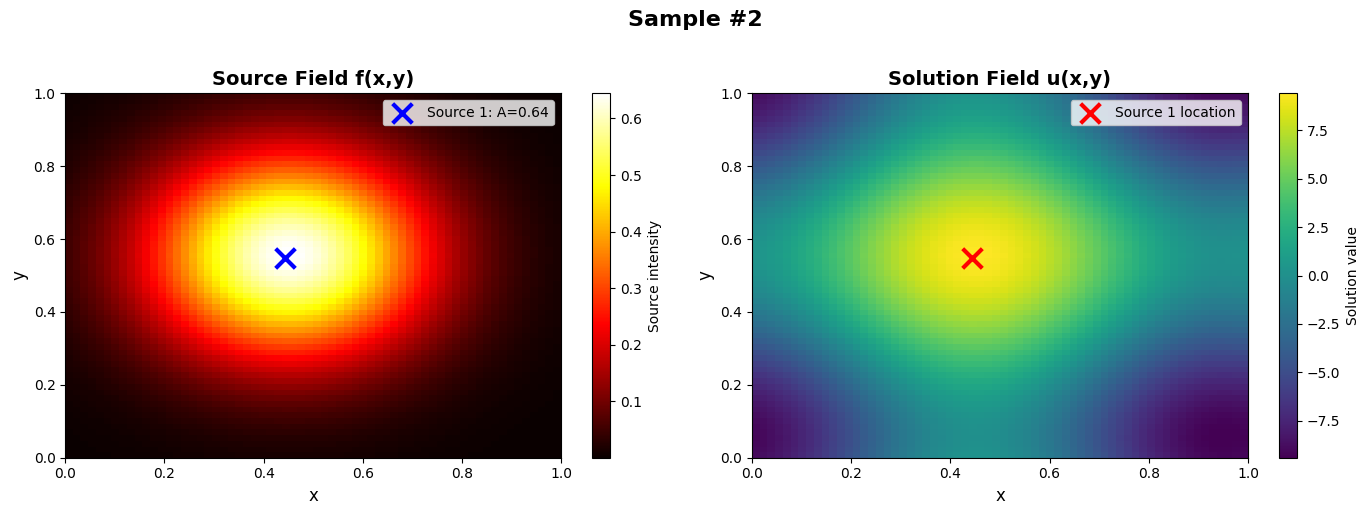


SAMPLE #3 - PARAMETERS

Source 1:
   Amplitude (A1):     0.2522
   Location (x1, y1):  (0.5444, 0.3214)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0000 / 0.2520
   Solution min/max:   -3.7148 / 3.7147



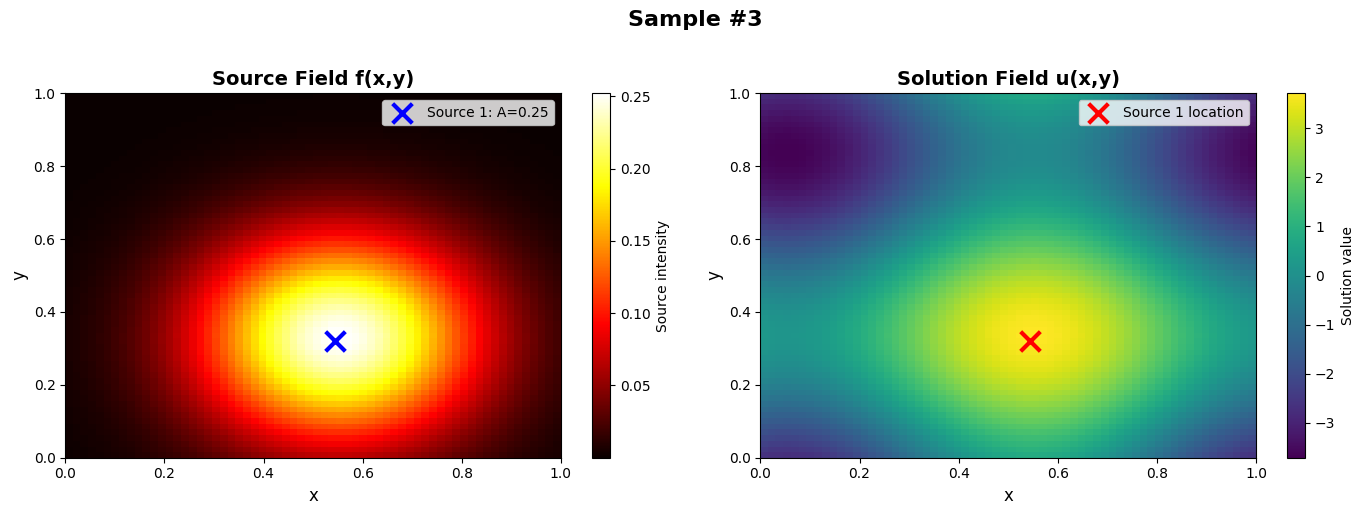


SAMPLE #4 - PARAMETERS

Source 1:
   Amplitude (A1):     0.9567
   Location (x1, y1):  (0.5894, 0.3070)
   Width (σ1):         0.2000

 Statistics:
   Source min/max:     0.0000 / 0.9562
   Solution min/max:   -14.1314 / 14.1307



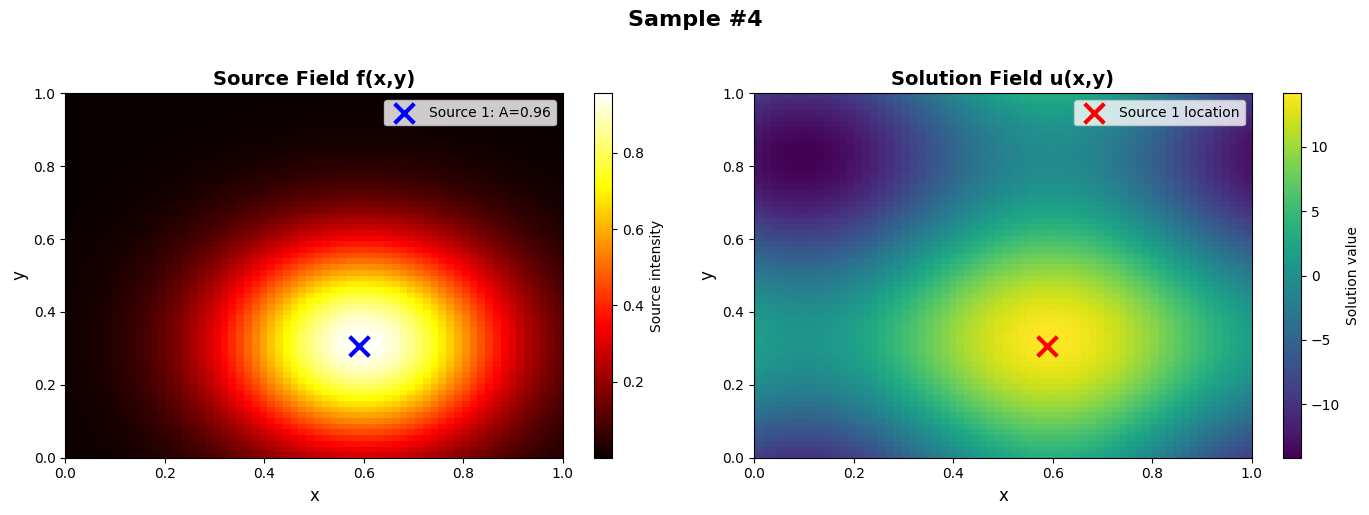

In [6]:
import matplotlib.pyplot as plt

def visualize_sample(idx, sources, solutions, params_array):
    """
    Visualize a single sample with source, solution, and parameters
    
    Parameters for 2 Gaussians:
    [A1, x1, y1, sigma1, A2, x2, y2, sigma2]
    """
    # Extract data
    source = sources[idx]
    solution = solutions[idx]
    params = params_array[idx]
    
    # Parse parameters
    A1, x1, y1, sigma1 = params[0:4]
    # A2, x2, y2, sigma2 = params[4:8]
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Source field f(x,y)
    im1 = axes[0].imshow(source, extent=[0, 1, 0, 1], origin='lower', 
                         cmap='hot', aspect='auto')
    axes[0].scatter([x1], [y1], c='blue', s=200, marker='x', linewidths=3, 
                    label=f'Source 1: A={A1:.2f}')
    # axes[0].scatter([x2], [y2], c='cyan', s=200, marker='x', linewidths=3, 
    #                 label=f'Source 2: A={A2:.2f}')
    axes[0].set_xlabel('x', fontsize=12)
    axes[0].set_ylabel('y', fontsize=12)
    axes[0].set_title(f'Source Field f(x,y)', fontsize=14, fontweight='bold')
    axes[0].legend(loc='upper right', fontsize=10)
    plt.colorbar(im1, ax=axes[0], label='Source intensity')
    
    # Plot 2: Solution field u(x,y)
    im2 = axes[1].imshow(solution, extent=[0, 1, 0, 1], origin='lower', 
                         cmap='viridis', aspect='auto')
    axes[1].scatter([x1], [y1], c='red', s=200, marker='x', linewidths=3, 
                    label='Source 1 location')
    # axes[1].scatter([x2], [y2], c='orange', s=200, marker='x', linewidths=3, 
    #                 label='Source 2 location')
    axes[1].set_xlabel('x', fontsize=12)
    axes[1].set_ylabel('y', fontsize=12)
    axes[1].set_title(f'Solution Field u(x,y)', fontsize=14, fontweight='bold')
    axes[1].legend(loc='upper right', fontsize=10)
    plt.colorbar(im2, ax=axes[1], label='Solution value')
    
    plt.suptitle(f'Sample #{idx}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Print parameters
    print(f"\n{'='*60}")
    print(f"SAMPLE #{idx} - PARAMETERS")
    print(f"{'='*60}")
    print(f"\nSource 1:")
    print(f"   Amplitude (A1):     {A1:.4f}")
    print(f"   Location (x1, y1):  ({x1:.4f}, {y1:.4f})")
    print(f"   Width (σ1):         {sigma1:.4f}")
    
    # print(f"\n Source 2:")
    # print(f"   Amplitude (A2):     {A2:.4f}")
    # print(f"   Location (x2, y2):  ({x2:.4f}, {y2:.4f})")
    # print(f"   Width (σ2):         {sigma2:.4f}")
    
    print(f"\n Statistics:")
    print(f"   Source min/max:     {source.min():.4f} / {source.max():.4f}")
    print(f"   Solution min/max:   {solution.min():.4f} / {solution.max():.4f}")
    # print(f"   Distance between sources: {np.sqrt((x2-x1)**2 + (y2-y1)**2):.4f}")
    print(f"{'='*60}\n")
    
    return fig


# Visualize first 3 samples
for i in range(5):
    fig = visualize_sample(i, sources, solutions, params_array)
    plt.savefig(f'sample_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [1]:
import numpy as np
import time
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


# =====================================================
#  Gaussian Source Utilities
# =====================================================

def gaussian_source(x, y, A, x0, y0, sigma):
    return A * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))


def multi_gaussian_source(X, Y, params):
    n = len(params) // 4
    f = np.zeros_like(X)

    for i in range(n):
        A, x0, y0, s = params[4*i : 4*i + 4]
        f += gaussian_source(X, Y, A, x0, y0, s)

    return f


# =====================================================
#   Helmholtz PDE Solver (Dirichlet)
# =====================================================

class HelmholtzSolver:
    def __init__(self, n_grid=64, k=np.pi):
        self.n = n_grid
        self.h = 1.0 / (n_grid - 1)
        self.k = k

    def solve(self, source):
        n, h, k = self.n, self.h, self.k
        N = n * n

        main = (-4 / h**2 + k**2) * np.ones(N)
        off = (1 / h**2) * np.ones(N - 1)
        off[n - 1::n] = 0
        offy = (1 / h**2) * np.ones(N - n)

        A = diags([main, off, off, offy, offy],
                  [0, 1, -1, n, -n],
                  format="lil")

        b = source.flatten()

        mask = np.zeros((n, n), dtype=bool)
        mask[0, :] = mask[-1, :] = True
        mask[:, 0] = mask[:, -1] = True
        boundary_idx = np.where(mask.flatten())[0]

        for idx in boundary_idx:
            A[idx, :] = 0
            A[idx, idx] = 1
            b[idx] = 0

        u = spsolve(A.tocsr(), b)
        return u.reshape((n, n))


# =====================================================
#   One Helmholtz sample
# =====================================================

def generate_helmholtz_sample(n_grid=64, n_sources=1, min_sep=0.25):

    x = np.linspace(0, 1, n_grid)
    y = np.linspace(0, 1, n_grid)
    X, Y = np.meshgrid(x, y)

    params_raw = []
    centers = []

    for i in range(n_sources):
        while True:
            A = np.random.uniform(2.0, 6.0)
            x0 = np.random.uniform(0.35, 0.65)
            y0 = np.random.uniform(0.35, 0.65)
            s = 0.2

            ok = True
            for (px, py) in centers:
                if np.sqrt((px - x0)**2 + (py - y0)**2) < min_sep:
                    ok = False
                    break

            if ok:
                centers.append((x0, y0))
                params_raw.append([A, x0, y0, s])
                break

    params_raw.sort(key=lambda p: p[1])
    params = [item for p in params_raw for item in p]

    source = multi_gaussian_source(X, Y, params)
    solver = HelmholtzSolver(n_grid=n_grid, k=2*np.pi)
    solution = solver.solve(source)

    return source, solution, params


# =====================================================
#   MAIN: Measure runtime for a single simulation
# =====================================================

if __name__ == "__main__":

    print("Running 1 Helmholtz simulation...")

    start = time.time()
    source, solution, params = generate_helmholtz_sample(
        n_grid=64,
        n_sources=1
    )
    end = time.time()

    print("Finished")
    print("Runtime seconds:", end - start)
    print("Source shape:", source.shape)
    print("Solution shape:", solution.shape)
    print("Params:", params)


Running 1 Helmholtz simulation...
Finished
Runtime seconds: 0.07916688919067383
Source shape: (64, 64)
Solution shape: (64, 64)
Params: [5.735381415876159, 0.6296860749450235, 0.6158809349762275, 0.2]
